# Module 3a: Dimension Reduction using Feature Selection
Charles Pang, PSUPR July 2024 <br><br>
**1. Filter Method:** a.Correlation, b.Anova <br>
**2. Wrapper Method:** c.Forward Feature Selection, d.Backward Feature Elimination, e.Recursive Feature Elimination <br>
**3. Embedded Methods:** f.Random Forest Classifier <br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from numpy import set_printoptions
# Select features according to the k highest scores
from sklearn.feature_selection import SelectKBest 
import warnings
warnings.filterwarnings('ignore')

In [49]:
import os

# Respect HPC allocation (replace 4 with the CPUs you actually requested)
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["JOBLIB_MAX_THREADS"] = "4"

In [2]:
#Load the dataset
data = pd.read_csv('Cancer.csv')
data = data.drop(columns=['id','Unnamed: 32'], axis=1)

print(data.shape)
print(data.isnull().values.any()) # check for any missing values
data.diagnosis.value_counts() # show the distribution of M/B

(569, 31)
False


diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
data.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [6]:
from sklearn.model_selection import train_test_split

target = 'diagnosis'
X = data.loc[:, data.columns != target]
Y = data.loc[:, data.columns == target]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=52)
features = pd.DataFrame(list(X_train.columns.values))

In [7]:
# Establish a baseline for comparison using LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=0.01) # smaller C means stronger regularization
lr = logreg.fit(X_train, y_train)
print("LogReg Training set score:",lr.score(X_train, y_train))
print("       Test set score    :",lr.score(X_test, y_test))

LogReg Training set score: 0.9221105527638191
       Test set score    : 0.9473684210526315


# 1. Filter Methods

## (a) Correlation Analysis

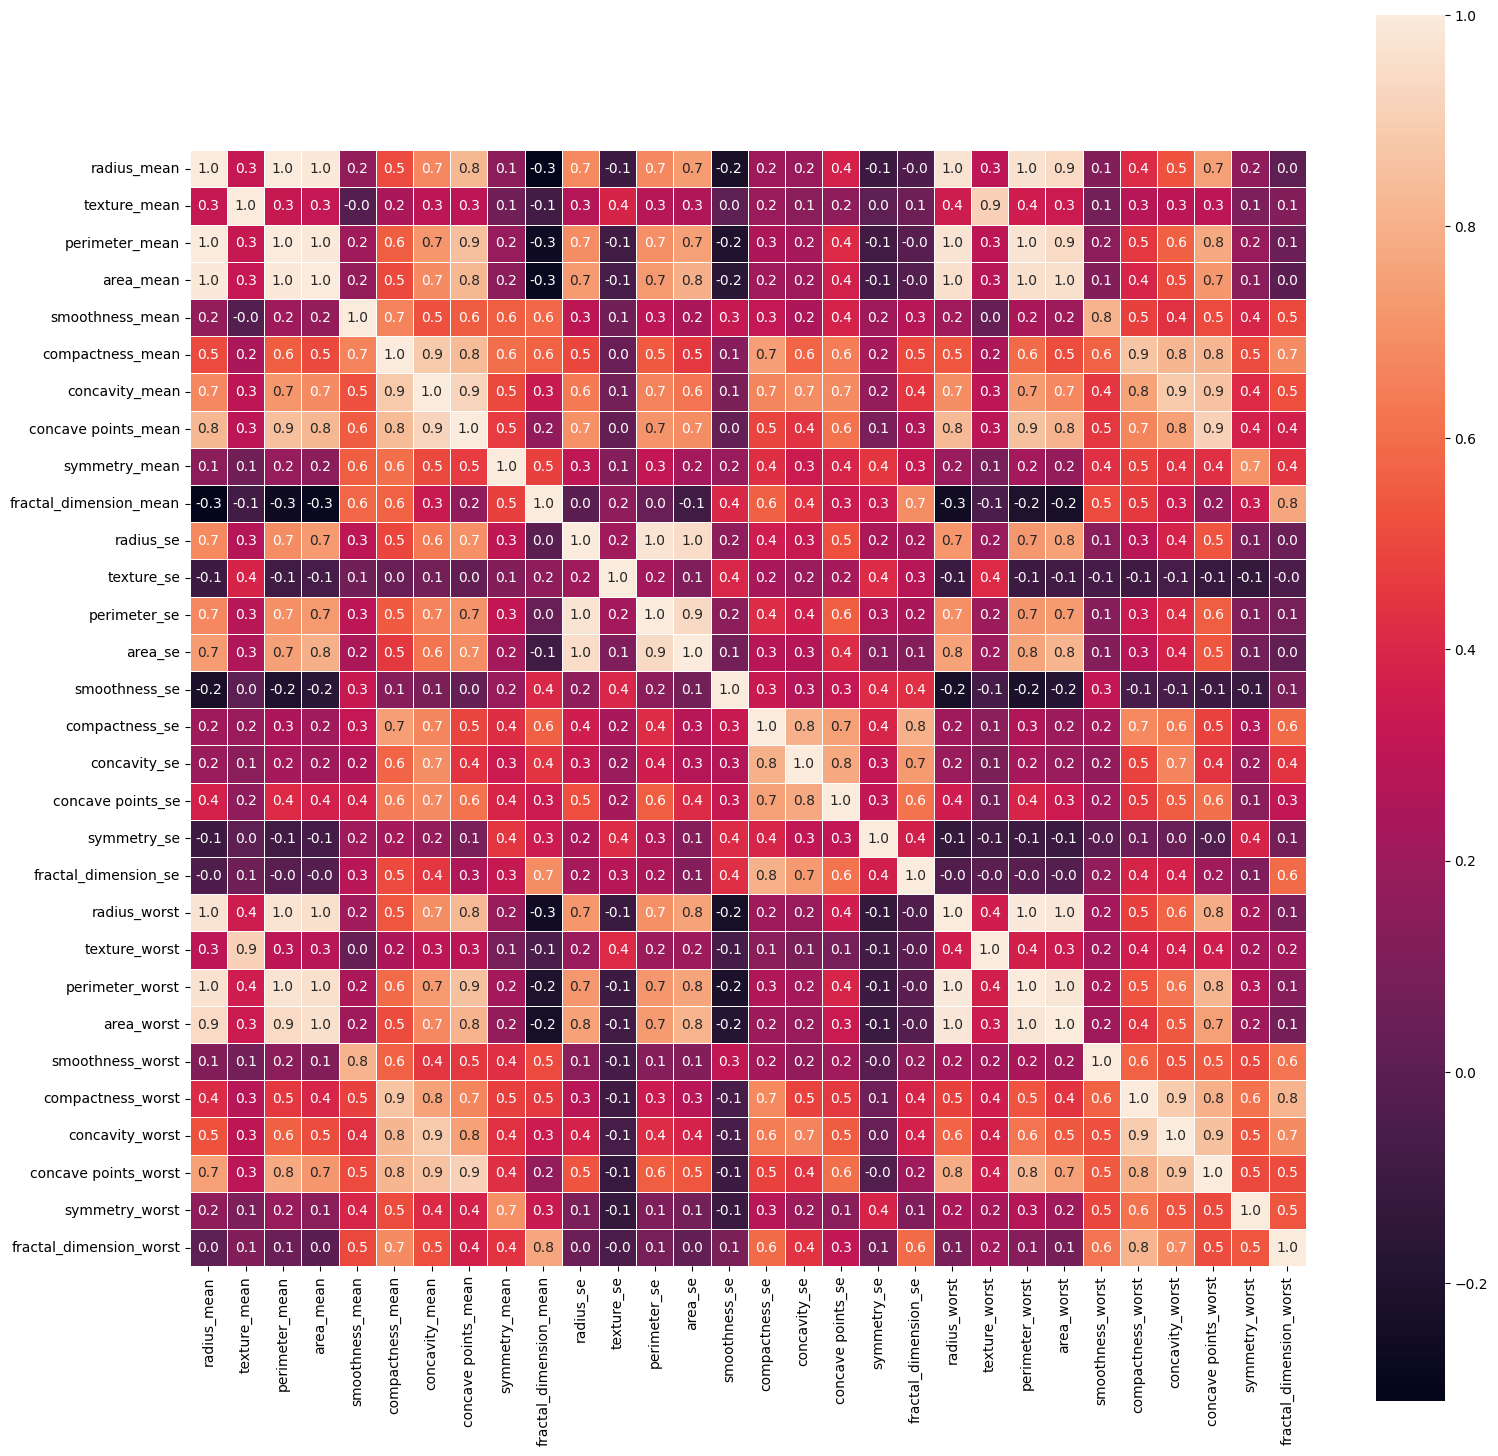

In [5]:
f = plt.figure(figsize=(18, 18))
ax = plt.subplot(aspect='equal')
corplot = sns.heatmap(X.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

# correlation >= 0.9
# 1)radius_mean: perimeter_mean, area_mean, radius_worst, perimeter_worst, area_worst 
# 2)texture_mean: texture_worst, Compactness_worst
# 3)Compactness_mean: concavity_mean
# 4)concave points_mean: concave points_worst
# 5)radius_se: perimeter_se, area_se
# 6)concavity_se: Compactness_se, concave points_se

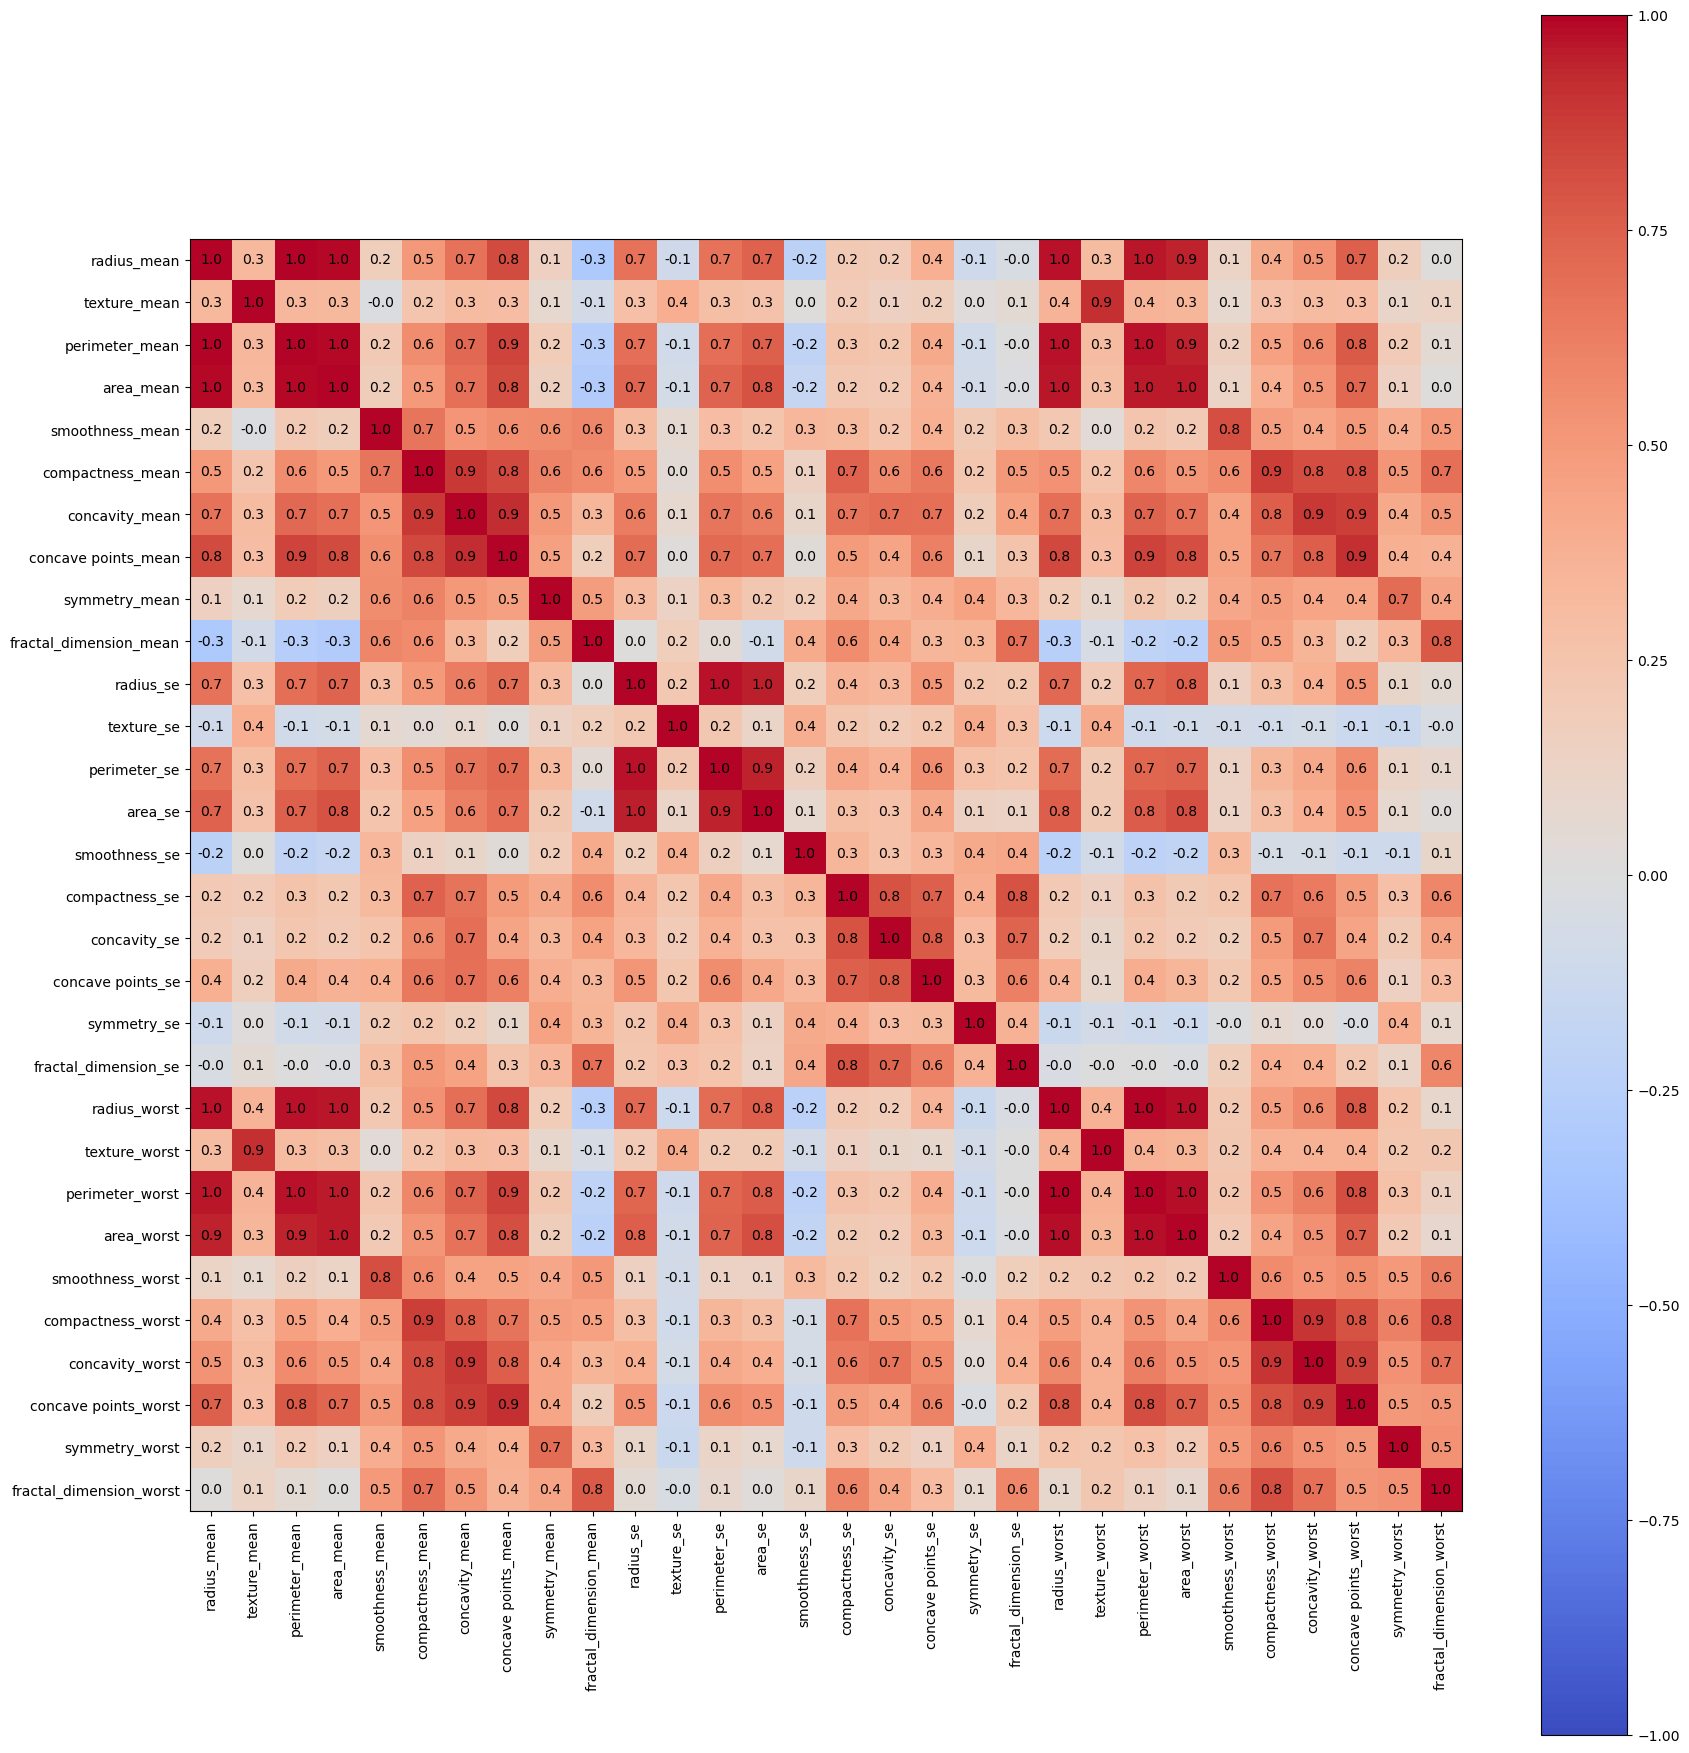

In [11]:
#one liner m-l-p heatmap for fun:
C=X.corr(); plt.figure(figsize=(18,18)); ax=plt.gca(); im=ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1); ax.set_xticks(range(len(C.columns))); ax.set_yticks(range(len(C.index))); ax.set_xticklabels(C.columns, rotation=90); ax.set_yticklabels(C.index); [ax.text(j,i,f"{C.values[i,j]:.1f}",ha="center",va="center",color="black") for i in range(C.shape[0]) for j in range(C.shape[1])]; plt.colorbar(im, ax=ax); ax.set_aspect("equal"); plt.tight_layout(); plt.show()


In [28]:
# Remove Corelated Features (>0.90) - requires domain expertise!
# you can try other different combinations

deselect = ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 
            'area_se', 'concavity_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 
            'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 
            'concave points_worst', 'fractal_dimension_worst']
len(deselect)

17

In [10]:
# test Logreg model with the reduced set of features
X_train_new = X_train.drop(deselect,axis = 1)
X_test_new = X_test.drop(deselect,axis = 1) 
print("old shape", X_train.shape)
print("new shape", X_train_new.shape)

lr = logreg.fit(X_train_new, y_train)
print("Corr Training set score DRAFT1:",lr.score(X_train_new, y_train))
print("     Test set score     DRAFT1:",lr.score(X_test_new, y_test))

old shape (398, 30)
new shape (398, 13)
Corr Training set score DRAFT1: 0.8894472361809045
     Test set score     DRAFT1: 0.8947368421052632


<div class="alert-danger">

**TASK#1:**

 - write code to automatically extract out the features pairs with r>0.9
 - Using domain knowledge or randomly remove one of the correlated pair
 - Use this reduced feature set to run prediction
 - Did you observe any difference in the performance?

</div>


In [13]:
X.corr().abs #comment for why abs is required:

<bound method NDFrame.abs of                          radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean                 1.000000      0.323782        0.997855   0.987357   
texture_mean                0.323782      1.000000        0.329533   0.321086   
perimeter_mean              0.997855      0.329533        1.000000   0.986507   
area_mean                   0.987357      0.321086        0.986507   1.000000   
smoothness_mean             0.170581     -0.023389        0.207278   0.177028   
compactness_mean            0.506124      0.236702        0.556936   0.498502   
concavity_mean              0.676764      0.302418        0.716136   0.685983   
concave points_mean         0.822529      0.293464        0.850977   0.823269   
symmetry_mean               0.147741      0.071401        0.183027   0.151293   
fractal_dimension_mean     -0.311631     -0.076437       -0.261477  -0.283110   
radius_se                   0.679090      0.275869        0.691765   0.732562   

In [14]:
# Step 1️⃣: Compute the correlation matrix for all numeric columns in X.
corr_matrix = X.corr()

# ❓What does X.corr() return?
# → A square DataFrame where rows and columns are features and each cell is the Pearson r between them.

# Step 2️⃣: Take absolute values.
corr_abs = corr_matrix.abs()

# Why abs()? Because both +0.95 and -0.95 mean *strong* linear relation in magnitude.
# Try removing .abs() once to see how it changes which pairs you catch.

# Step 3️⃣: Prepare an empty list to hold the strongly-correlated pairs we find.
high_corr_pairs = []

# Step 4️⃣: Double loop over the *upper triangle* only (so each pair once).
for i, col1 in enumerate(corr_abs.columns):       # iterate feature i
    for col2 in corr_abs.columns[i + 1:]:         # iterate features *after* i (avoid repeats and self)
        r_val = corr_abs.at[col1, col2]           # fetch the absolute correlation between these two
        if r_val > 0.9:                           # ✅ threshold: strong correlation
            # Append a tuple of (feature_1, feature_2, correlation)
            high_corr_pairs.append((col1, col2, r_val))
        # 💭 Try lowering threshold to 0.7 — what happens to list size?

# Step 5️⃣: Convert the list of tuples to a DataFrame for readability / export.
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "correlation"]
).sort_values("correlation", ascending=False)

# Step 6️⃣: Inspect the top few pairs.
print(high_corr_df.head())

         feature_1        feature_2  correlation
0      radius_mean   perimeter_mean     0.997855
18    radius_worst  perimeter_worst     0.993708
1      radius_mean        area_mean     0.987357
6   perimeter_mean        area_mean     0.986507
19    radius_worst       area_worst     0.984015


In [15]:
high_corr_df

,feature_1,feature_2,correlation
0,radius_mean,perimeter_mean,0.997855
18,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
6,perimeter_mean,area_mean,0.986507
19,radius_worst,area_worst,0.984015
20,perimeter_worst,area_worst,0.977578
15,radius_se,perimeter_se,0.972794
8,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
7,perimeter_mean,radius_worst,0.969476


In [17]:
deselect=['radius_mean','radius_worst']

In [18]:
# test Logreg model with the reduced set of features
X_train_new = X_train.drop(deselect,axis = 1)
X_test_new = X_test.drop(deselect,axis = 1)
print("old shape", X_train.shape)
print("new shape", X_train_new.shape)

lr = logreg.fit(X_train_new, y_train)
print("Corr Training set score:",lr.score(X_train_new, y_train))
print("     Test set score    :",lr.score(X_test_new, y_test))

old shape (398, 30)
new shape (398, 28)
Corr Training set score: 0.9221105527638191
     Test set score    : 0.9473684210526315


How is the model performance compared with baseline LogReg?


>It stayed the same, meaning radius features were redundant.

## (b) Anova (f_classif)

<div class="alert-danger">
    
**TASK#2** 
 - Set the number of features you want to select as imput for predictive modeling
 - Run the Anova and Wrapper methods to select (f) features and check on the model performance
 - Experiment with values of f
 - Do you observe any peformance difference among the different features selection methods?

</div>

In [29]:
f = len(features)-len(deselect) # number of reduced features to use

In [25]:
f = 15 #lets reduce to 24 from 30 features

In [30]:
from sklearn.feature_selection import f_classif

Anova = SelectKBest(score_func=f_classif, k=f).fit(X_train, y_train)
AnovaRanking = pd.DataFrame({'Feature':list(X_train.columns),'Scores':Anova.scores_})
AnovaRanking.sort_values(by='Scores', ascending=False, inplace=True)

print('Top', f, 'selected:')
display(AnovaRanking.head(f))

Top 13 selected:


,Feature,Scores
27,concave points_worst,676.716398
7,concave points_mean,630.854979
22,perimeter_worst,595.995645
20,radius_worst,559.930079
2,perimeter_mean,462.976937
23,area_worst,458.134934
0,radius_mean,419.834601
3,area_mean,409.643914
6,concavity_mean,407.978442
26,concavity_worst,302.023031


#### Use Anova Selected Features on logreg model

In [31]:
X_train_new = Anova.transform(X_train) 
X_test_new = Anova.transform(X_test)

lr = logreg.fit(X_train_new, y_train)
print("Anova Training set score:",lr.score(X_train_new, y_train))
print("      Test set score    :",lr.score(X_test_new, y_test))
print('\nHow is the model performance compared with the original LogReg?')

Anova Training set score: 0.9346733668341709
      Test set score    : 0.9532163742690059

How is the model performance compared with the original LogReg?


* with 24 Anova selected features, model performance is slightly better than the baseline LogReg\
Anova Training set score: 0.919597989949748\
Test set score    : 0.9473684210526315

* with 15, model is performing even better than baseline LogReg\
Anova Training set score: 0.9195979899497487\
      Test set score    : 0.9473684210526315
* with 13, performance is even better than 15, both train and test improved
* Anove is much better than just dropping the features directly based on correlation


# 2. Wrapper Methods

In [32]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.svm import LinearSVC
# I am using the Linear Support Vector Classifier algoritm 
# Others are SVC(other kernels), OLS, Linear/Log Regression, Decision Trees, etc.

<div class="alert-danger">

**TASK#3** 

 - Try different algorithms as wrappers
     - from sklearn.tree import DecisionTreeClassifier
     - from sklearn.linear_model import LogisticRegression
     - from sklearn.svm import SVC
 - What do you observe with the use of different **wrapper** algorithms?

</div>

wrapper methods work very differently — they actually train a model several times to find the best subset of features -- uses an actual ML model (a classifier or regressor) to evaluate subsets of features based on how well the model performs

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

In [34]:
base_model = logreg

#### play with sequential feature selector

In [35]:
# Choose forward=True for Forward Selection (start with 0 features, add best each step)
# or forward=False for Backward Elimination (start with all, remove worst each step)
sfs = SFS(
    estimator=base_model,         # model whose performance we’ll wrap
    n_features_to_select=5,       # how many features to keep at the end
    direction='forward',          # 'forward' or 'backward'
    scoring='accuracy',           # metric to evaluate model performance
    cv=5,                         # cross-validation folds
    n_jobs=-1                     # use all cores for speed
)

# fit the selector to your training data
sfs.fit(X_train, y_train)

,estimator,LogisticRegression(C=0.01)
,n_features_to_select,5
,tol,None
,direction,'forward'
,scoring,'accuracy'
,cv,5
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01


In [36]:
#examine results
# indices of the selected features
selected_idx = sfs.get_support(indices=True)

# names of the selected columns
selected_features = X_train.columns[selected_idx]

print("Selected features:\n", selected_features.tolist())

Selected features:
 ['texture_mean', 'smoothness_mean', 'area_se', 'texture_worst', 'perimeter_worst']


In [37]:
#ranked dataframe:
sfs_ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": sfs.get_support().astype(int)
})

display(sfs_ranking[sfs_ranking["Selected"] == 1])

,Feature,Selected
1,texture_mean,1
4,smoothness_mean,1
13,area_se,1
21,texture_worst,1
22,perimeter_worst,1


## (c) Forward Feature Selection (FFS)

In [38]:
# note that you could perform a Hyperparameter estimation for C

model = LinearSVC(C=0.5, random_state = 42) # higher values tend to overfit
model.fit(X_train, y_train)

sfs = SFS(estimator=model, n_features_to_select=f, direction='forward').fit(X_train, y_train)
print('FFS:'f'{features[sfs.get_support()]}')
print('\nCompare the selected features here with the ealier methods.\n')

FFS:                         0
0              radius_mean
1             texture_mean
2           perimeter_mean
4          smoothness_mean
5         compactness_mean
6           concavity_mean
7      concave points_mean
8            symmetry_mean
9   fractal_dimension_mean
14           smoothness_se
23              area_worst
25       compactness_worst
27    concave points_worst

Compare the selected features here with the ealier methods.



In [39]:
#sfs.transform(X): Reduce X to the FFS selected features.
X_train_new = sfs.transform(X_train)
X_test_new = sfs.transform(X_test)

# Run the baseline Logreg model with the SFS reduced dataset
lr = logreg.fit(X_train_new, y_train)
print('Forward Feature Selection [FFS] using SVC\n')
print('Test models with FFS Reduced Features::\n')
print('  LogReg Train:', lr.score(X_train_new, y_train))
print('  LogReg Test :', lr.score(X_test_new, y_test))
print('  *** Compare this result with the baseline Logreg\n')

# Run SVC Model using the FFS Reduced Features
# note that we cannot set random state - so every run will be different
sfs_test = model.fit(X_train_new, y_train)
print('  SVC Train:',sfs_test.score(X_train_new, y_train))
print('  SVC Test :',sfs_test.score(X_test_new, y_test))
print('  *** Compare this result with the previous models\n')

Forward Feature Selection [FFS] using SVC

Test models with FFS Reduced Features::

  LogReg Train: 0.9221105527638191
  LogReg Test : 0.9473684210526315
  *** Compare this result with the baseline Logreg

  SVC Train: 0.9623115577889447
  SVC Test : 0.9707602339181286
  *** Compare this result with the previous models



SVC performs better than both LogReg on FFS reduced features as well as any other combination of LogReg using Anova etc that we tried above

## (d) Backward Feature Elimination (BFE)

In [40]:
sfs = SFS(model, n_features_to_select=f, direction='backward').fit(X_train, y_train)
print('BFE:'f'{features[sfs.get_support()]}')
print('\nCompare the selected features here with the ealier methods.\n')

BFE:                          0
0               radius_mean
3                 area_mean
11               texture_se
12             perimeter_se
13                  area_se
20             radius_worst
21            texture_worst
22          perimeter_worst
23               area_worst
25        compactness_worst
27     concave points_worst
28           symmetry_worst
29  fractal_dimension_worst

Compare the selected features here with the ealier methods.



In [41]:
X_train_new = sfs.transform(X_train)
X_test_new = sfs.transform(X_test)

# Run the baseline Logreg model with the SFS reduced dataset
lr = logreg.fit(X_train_new, y_train)

print('Backward Feature Elimination [BFE] using SVC\n')
print('Test models with BFE Reduced Features::\n')
print('  LogReg Train:', lr.score(X_train_new, y_train))
print('  LogReg Test :', lr.score(X_test_new, y_test))
print('  *** Compare this result with the baseline Logreg\n')

# Run LinearSVC Model using the BFE Reduced Features
sfs_test = model.fit(X_train_new, y_train)
print('  SVC Train:',sfs_test.score(X_train_new, y_train))
print('  SVC Test :',sfs_test.score(X_test_new, y_test))
print('  *** Compare this result with the previous models\n')


Backward Feature Elimination [BFE] using SVC

Test models with BFE Reduced Features::

  LogReg Train: 0.9447236180904522
  LogReg Test : 0.9590643274853801
  *** Compare this result with the baseline Logreg

  SVC Train: 0.9597989949748744
  SVC Test : 0.9707602339181286
  *** Compare this result with the previous models



LogReg performed better with backward feature selection than forward feature selection\
SVC was comparable for both FFS and BFE

## (e) Recursive Feature Elimination- RFE

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [42]:
from sklearn.feature_selection import RFE
# step: number of features to remove at each iteration
rfe = RFE(estimator=model, n_features_to_select=f, step=1).fit(X_train, y_train)

RFEfeatures = pd.DataFrame({'Feature':list(X_train.columns),'Scores':rfe.ranking_})
RFEfeatures.sort_values(by='Scores', ascending=True, inplace=True)
display(RFEfeatures.head(20))
print('\nCompare the selected features here with the ealier methods.\n')

,Feature,Scores
0,radius_mean,1
2,perimeter_mean,1
6,concavity_mean,1
5,compactness_mean,1
7,concave points_mean,1
15,compactness_se,1
10,radius_se,1
8,symmetry_mean,1
25,compactness_worst,1
26,concavity_worst,1



Compare the selected features here with the ealier methods.



In [43]:
# test the reduced dataset 
X_train_new = rfe.transform(X_train)
X_test_new = rfe.transform(X_test)

# Run the baseline Logreg model with the SFS reduced dataset
lr = logreg.fit(X_train_new, y_train)

print('Recursive Feature Elimination [RFE] using SVC\n')
print('Test models with RFE Reduced Features::\n')
print('  LogReg Train:', lr.score(X_train_new, y_train))
print('  LogReg Test :', lr.score(X_test_new, y_test))
print('  *** Compare this result with the baseline Logreg\n')

# Run LinearSVC Model using the RFE Reduced Features
sfs_test = model.fit(X_train_new, y_train)
print('  SVC Train:',sfs_test.score(X_train_new, y_train))
print('  SVC Test :',sfs_test.score(X_test_new, y_test))
print('  *** Compare this result with the previous models\n')

Recursive Feature Elimination [RFE] using SVC

Test models with RFE Reduced Features::

  LogReg Train: 0.8793969849246231
  LogReg Test : 0.9064327485380117
  *** Compare this result with the baseline Logreg

  SVC Train: 0.9195979899497487
  SVC Test : 0.9473684210526315
  *** Compare this result with the previous models



Recursive feature selection has performed poorly compared to both forward and backward selection\
This may be because RFE eliminates features based on the model's weights, which can be misleading if features are correlated or if the model is not well-tuned.

<div class="alert-danger">
    
**TASK#4** 
 - Compare and contrast the directions: Forward, Backward and Recursive
 - which direction yields the best performance?
 - Explain/justify what you think so?
</div>

* Forward and Backward are better than recursive feature elimination in this case\
* Forward selection starts with no features and adds the most significant ones, while backward elimination starts with all features and removes the least significant ones. Both methods evaluate the model's performance at each step, leading to a more optimal feature set.\
* Recursive elimination, on the other hand, may remove important features too early based on the model's weights, which can be misleading if features are correlated or if the model is not well-tuned.\
* In this ENTIRE NOTEBOOK, forward elimination with SVC yielded the best performance, showing that it retained the most relevant features while discarding redundant ones.

# 3. Embedded Methods

## (f) Random Forest Classifier - Feature importance is part of output

In [44]:
# Run a RFC model using ALL features and let it find important features using weights
# To use RF purely for feature selection, we have to use 'SelectFromModel' (see next cell)
# However, note that SelectFromModel object has no attribute 'predict'

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score

# n_estimators = number of trees to build
# oob = out-of-bag scores
rfc = RandomForestClassifier(n_estimators=500, oob_score=True, random_state=43)      
rfc = rfc.fit(X_train,y_train)

accuracy = accuracy_score(y_test, rfc.predict(X_test))
print('RandomForest Accuracy:', accuracy)
print('OOB error   :', rfc.oob_score_)
final_df = pd.DataFrame({"Features": X_train.columns, "Importances":rfc.feature_importances_})
# Sklearn: "computed as the mean and standard deviation of accumulation of the impurity decrease within each tree."

final_df.set_index('Importances')
final_df.sort_values('Importances',ascending = False, inplace=True)
print('\nSet of *Ranked* important features determined by the RF algorithm')
print('\nCompare the top',f,'selected features here with the ealier methods.\n')

#display(final_df.head(10)) #note I used f=10)
display(final_df.head(f)) 

# final_df['Importances'].sum() sum of importance (weights) = 1.0
print('\nThe total importance (out of 1.0) from top 10 features:')
final_df['Importances'].head(10).sum() #sum of importance (weights)


RandomForest: 0.9766081871345029
OOB error   : 0.957286432160804

Set of *Ranked* important features determined by the RF algorithm

Compare the top 13 selected features here with the ealier methods.



,Features,Importances
27,concave points_worst,0.144156
22,perimeter_worst,0.129047
23,area_worst,0.108481
7,concave points_mean,0.100994
20,radius_worst,0.092711
6,concavity_mean,0.058696
2,perimeter_mean,0.048802
3,area_mean,0.048656
26,concavity_worst,0.038658
0,radius_mean,0.034895



The total importance (out of 1.0) from top 10 features:


np.float64(0.8050963729741497)

<div class="alert-danger">

**TASK#5** 
 - Refer to 
     - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
 - Add parameters such as <br> n_estimators=1000, <br>criterion='gini', <br>max_depth=??, <br>min_samples_split=?, <br>min_samples_leaf=?, <br>min_weight_fraction_leaf=0.5, <br>max_features='sqrt', <br>max_leaf_nodes=10
 - Review the model performance after manually tuning the parameters
 - Or you may use GridSearchcv()


In [50]:
from joblib import parallel_backend
import joblib, os
print("Detected:", joblib.cpu_count(), "visible CPUs")
print("OMP threads:", os.getenv("OMP_NUM_THREADS"))
print("MKL threads:", os.getenv("MKL_NUM_THREADS"))

Detected: 4 visible CPUs
OMP threads: 4
MKL threads: 4


In [51]:
# RFC Model optimization using GridSearchCV
# ===========================
# 1️⃣ Import the required tools
# ===========================
from sklearn.model_selection import GridSearchCV        # for hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier     # our model
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd                                     # to view the results cleanly

# ========================================
# 2️⃣ Define a base RandomForestClassifier
# ========================================
# We keep oob_score=True for later review; note it works only if bootstrap=True
rfc = RandomForestClassifier(
    bootstrap=True,            # enable bootstrap sampling (required for oob_score)
    oob_score=True,
    random_state=43, #random state is fixed to help us verify changes in performance
    n_jobs=2                  # use all cores for faster training
)
# ==================================================
# 3️⃣ Define the hyperparameter grid to search over
# ==================================================
# Each key corresponds to a model argument, each value is a list of possible settings.
param_grid = {
    "n_estimators": [500, 1000],               # number of trees in the forest
    "criterion": ["gini", "entropy"],          # how to measure split quality
    "max_depth": [None, 5, 10, 20],            # tree depth; None = full growth
    "min_samples_split": [2, 5, 10],           # min samples to split an internal node
    "min_samples_leaf": [1, 2, 4],             # min samples at a leaf node
    "min_weight_fraction_leaf": [0.0, 0.25, 0.5], # minimum weighted fraction of leaf
    "max_features": ["sqrt", "log2"],          # number of features to consider at split
    "max_leaf_nodes": [None, 10, 20]           # cap number of leaf nodes per tree
}

# 💭 Notice: The grid is a *cartesian product* of all choices.
# Total models = product(len(values)). With many params, training explodes!

# =========================================
# 4️⃣ Setup the GridSearchCV wrapper itself
# =========================================
# It will train multiple RandomForest models (one for each combination of params),
# evaluate them using cross-validation, and keep track of the best one.

grid_search = GridSearchCV(
    estimator=rfc,              # base model to optimize
    param_grid=param_grid,      # search space
    scoring="accuracy",         # metric to optimize; can change to "f1" etc.
    cv=5,                       # 5-fold cross validation ==> bias-variance tradeoff between 3-fold vs 10-fold CV
    n_jobs=4,                  # parallelize across CPUs -- run folds & parameter sets in parallel
    verbose=2                   # show training progress
)

# =================================
# 5️⃣ Fit the grid search on training data
# =================================
grid_search.fit(X_train, y_train)

# ===============================
# 6️⃣ Inspect best parameters found
# ===============================
print("Best parameters found:\n", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# ================================================
# 7️⃣ Evaluate on the test set using best estimator
# ================================================
best_rfc = grid_search.best_estimator_             # retrieve the tuned model
y_pred = best_rfc.predict(X_test)                  # predict labels on unseen data
test_acc = accuracy_score(y_test, y_pred)          # compute test accuracy
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===================================
# 8️⃣ Review model performance summary
# ===================================
# create a DataFrame to inspect all tried combinations (sorted by rank)
results_df = pd.DataFrame(grid_search.cv_results_)
summary = results_df[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values(by="rank_test_score")
display(summary.head(10))  # show top 10 performing parameter combos

# ==================================================
# 9️⃣ Check OOB score of best model
# ==================================================
if hasattr(best_rfc, "oob_score_"):
    print("OOB score of best estimator:", best_rfc.oob_score_)



Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
[CV] END criterion=gini, max_depth=None, max_features=sqrt, max_leaf_nodes=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, n_estimators=500; total time=   0.9s
[CV] END criterion=gini, max_depth=None, max_features=sqrt, max_leaf_nodes=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, n_estimators=500; total time=   0.9s
[CV] END criterion=gini, max_depth=None, max_features=sqrt, max_leaf_nodes=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, n_estimators=1000; total time=   1.7s
[CV] END criterion=gini, max_depth=None, max_features=sqrt, max_leaf_nodes=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.25, n_estimators=500; total time=   0.8s
[CV] END criterion=gini, max_depth=None, max_features=sqrt, max_leaf_nodes=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.25, n_estimators=1000; tota

KeyboardInterrupt: 

## (g) Random Forest Classifier - Using SelectFromModel to extract important features

In [52]:
# Use the RF model for Feature Selection using SelectFromModel to extract important features 
# The output feature set is consistent with the RFC model in 3(f)
# NOTE: SelectFromModel' object has no attribute 'predict'
#       There is no k - it outputs based on some internal threshold (no iterations like RFE)
#       In this case, it gives 10 features that are not prioritized
#              
from sklearn.feature_selection import SelectFromModel

selrfc = SelectFromModel(RandomForestClassifier(n_estimators = 500, random_state=43))
selrfc.fit(X_train, y_train)
selrfc.get_support()

selected_feat = X_train.columns[(selrfc.get_support())]

print('Important Features selected by SelectFromModel(RF):\n',pd.DataFrame(selected_feat)) 
print('\nNumber of Feaures (Not Ranked) selected:',len(selected_feat))
# Note: NOT Ranked
print('\nCompare these selected features with the earlier methods')

Important Features selected by SelectFromModel(RF):
                       0
0           radius_mean
1        perimeter_mean
2             area_mean
3        concavity_mean
4   concave points_mean
5          radius_worst
6       perimeter_worst
7            area_worst
8       concavity_worst
9  concave points_worst

Number of Feaures (Not Ranked) selected: 10

Compare these selected features with the earlier methods


In [53]:
# Run the RFC model again but with the reduced dataset (just an experiment)
# The result is consistent with the RFC model in 3(f)
X_train_new = selrfc.transform(X_train)
X_test_new = selrfc.transform(X_test)

rfc = RandomForestClassifier(n_estimators=500, random_state=43)      
rfc = rfc.fit(X_train_new,y_train)
accuracy = accuracy_score(y_test, rfc.predict(X_test_new))
print('RandomForest : ', accuracy)

RandomForest :  0.9766081871345029


In [54]:
print('Use the RandomForest Important Features on Baseline LogReg model\n')
lr = logreg.fit(X_train_new, y_train)
print('LogReg Training:', lr.score(X_train_new, y_train))
print('           Test:', lr.score(X_test_new, y_test))
print('\nCompare these results with the previous models\n')

Use the RandomForest Important Features on Baseline LogReg model

LogReg Training: 0.9271356783919598
           Test: 0.9707602339181286

Compare these results with the previous models



This gives high test score for LogReg